In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pickle
import json
import os

# Load main dataset
df = pd.read_csv('/dataset.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print()
print("First 5 rows:")
print(df.head())
print()
print("Missing values:")
print(df.isnull().sum())
print()
print("Total unique diseases:", df['Disease'].nunique())
print()
print("Disease distribution:")
print(df['Disease'].value_counts())


Shape: (4920, 18)
Columns: ['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']

First 5 rows:
            Disease   Symptom_1              Symptom_2              Symptom_3  \
0  Fungal infection     itching              skin_rash   nodal_skin_eruptions   
1  Fungal infection   skin_rash   nodal_skin_eruptions    dischromic _patches   
2  Fungal infection     itching   nodal_skin_eruptions    dischromic _patches   
3  Fungal infection     itching              skin_rash    dischromic _patches   
4  Fungal infection     itching              skin_rash   nodal_skin_eruptions   

              Symptom_4 Symptom_5 Symptom_6 Symptom_7 Symptom_8 Symptom_9  \
0   dischromic _patches       NaN       NaN       NaN       NaN       NaN   
1                   NaN       NaN       NaN       NaN       NaN       NaN   

In [ ]:
# Symptom columns list
symptom_cols = [col for col in df.columns if col.startswith('Symptom')]
print("Symptom columns:", symptom_cols)
print()

# Clean all symptom columns
for col in symptom_cols:
    df[col] = df[col].str.strip().str.lower().str.replace(' ', '_', regex=False).str.replace('__', '_', regex=False)

# Clean disease column
df['Disease'] = df['Disease'].str.strip()

print("After cleaning sample:")
print(df.head())
print()
print("Sample Symptom_4 values:")
print(df['Symptom_4'].dropna().unique()[:10])

Symptom columns: ['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']

After cleaning sample:
            Disease  Symptom_1             Symptom_2             Symptom_3  \
0  Fungal infection    itching             skin_rash  nodal_skin_eruptions   
1  Fungal infection  skin_rash  nodal_skin_eruptions    dischromic_patches   
2  Fungal infection    itching  nodal_skin_eruptions    dischromic_patches   
3  Fungal infection    itching             skin_rash    dischromic_patches   
4  Fungal infection    itching             skin_rash  nodal_skin_eruptions   

            Symptom_4 Symptom_5 Symptom_6 Symptom_7 Symptom_8 Symptom_9  \
0  dischromic_patches       NaN       NaN       NaN       NaN       NaN   
1                 NaN       NaN       NaN       NaN       NaN       NaN   
2                 NaN       NaN    

In [ ]:
# Load severity file
df_severity = pd.read_csv('/Symptom-severity.csv')

# Clean severity file
df_severity.columns = df_severity.columns.str.strip()
df_severity['Symptom'] = df_severity['Symptom'].str.strip().str.lower().str.replace(' ', '_', regex=False).str.replace('__', '_', regex=False)

print("Severity file:")
print(df_severity.head(10))
print()
print("Shape:", df_severity.shape)
print()
print("Chest pain weight:", df_severity[df_severity['Symptom'] == 'chest_pain']['weight'].values)

Severity file:
                Symptom  weight
0               itching       1
1             skin_rash       3
2  nodal_skin_eruptions       4
3   continuous_sneezing       4
4             shivering       5
5                chills       3
6            joint_pain       3
7          stomach_pain       5
8               acidity       3
9      ulcers_on_tongue       4

Shape: (133, 2)

Chest pain weight: [7]


In [ ]:
# All unique symptoms nikalo
all_symptoms = []

for col in symptom_cols:
    unique_vals = df[col].dropna().unique().tolist()
    all_symptoms.extend(unique_vals)

all_symptoms = list(set(all_symptoms))
all_symptoms.sort()

print(f"Total unique symptoms: {len(all_symptoms)}")
print()
print("Sample symptoms:")
print(all_symptoms[:20])

Total unique symptoms: 131

Sample symptoms:
['abdominal_pain', 'abnormal_menstruation', 'acidity', 'acute_liver_failure', 'altered_sensorium', 'anxiety', 'back_pain', 'belly_pain', 'blackheads', 'bladder_discomfort', 'blister', 'blood_in_sputum', 'bloody_stool', 'blurred_and_distorted_vision', 'breathlessness', 'brittle_nails', 'bruising', 'burning_micturition', 'chest_pain', 'chills']


In [ ]:
# Har row ke symptoms ek list mein combine karo
def get_symptoms_list(row):
    symptoms = []
    for col in symptom_cols:
        if pd.notna(row[col]):
            symptoms.append(row[col])
    return symptoms

df['all_symptoms'] = df.apply(get_symptoms_list, axis=1)

print("Sample all_symptoms:")
print(df['all_symptoms'].head())
print()

# MultiLabelBinarizer apply karo
mlb = MultiLabelBinarizer()
symptom_encoded = mlb.fit_transform(df['all_symptoms'])

symptom_df = pd.DataFrame(symptom_encoded, columns=mlb.classes_)

print("Encoded shape:", symptom_df.shape)
print()
print("Sample encoded (first 5 rows, first 10 cols):")
print(symptom_df.iloc[:5, :10])

Sample all_symptoms:
0    [itching, skin_rash, nodal_skin_eruptions, dis...
1    [skin_rash, nodal_skin_eruptions, dischromic_p...
2    [itching, nodal_skin_eruptions, dischromic_pat...
3             [itching, skin_rash, dischromic_patches]
4           [itching, skin_rash, nodal_skin_eruptions]
Name: all_symptoms, dtype: object

Encoded shape: (4920, 131)

Sample encoded (first 5 rows, first 10 cols):
   abdominal_pain  abnormal_menstruation  acidity  acute_liver_failure  \
0               0                      0        0                    0   
1               0                      0        0                    0   
2               0                      0        0                    0   
3               0                      0        0                    0   
4               0                      0        0                    0   

   altered_sensorium  anxiety  back_pain  belly_pain  blackheads  \
0                  0        0          0           0           0   
1             

In [ ]:
# Severity weights multiply karo
print("Adding severity weights...")

for symptom in mlb.classes_:
    weight_row = df_severity[df_severity['Symptom'] == symptom]
    if len(weight_row) > 0:
        weight = weight_row['weight'].values[0]
        symptom_df[symptom] = symptom_df[symptom] * weight

print("After severity weights:")
print(symptom_df.iloc[:5, :10])
print()

# Verify
print("Chest pain weight in encoded data:")
print(symptom_df['chest_pain'].value_counts())

Adding severity weights...
After severity weights:
   abdominal_pain  abnormal_menstruation  acidity  acute_liver_failure  \
0               0                      0        0                    0   
1               0                      0        0                    0   
2               0                      0        0                    0   
3               0                      0        0                    0   
4               0                      0        0                    0   

   altered_sensorium  anxiety  back_pain  belly_pain  blackheads  \
0                  0        0          0           0           0   
1                  0        0          0           0           0   
2                  0        0          0           0           0   
3                  0        0          0           0           0   
4                  0        0          0           0           0   

   bladder_discomfort  
0                   0  
1                   0  
2                   0  

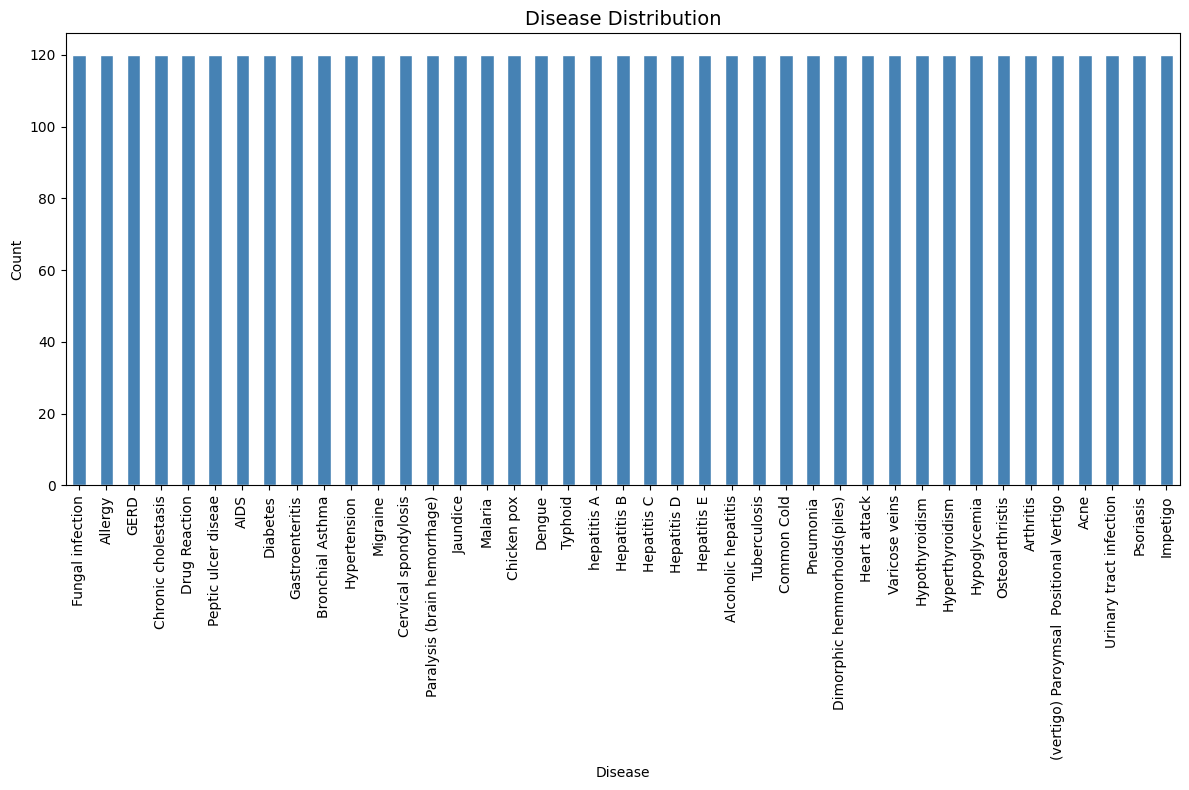

Most common disease: Fungal infection
Least common disease: Impetigo

Top 10 most common symptoms:
fatigue              1932
vomiting             1914
high_fever           1362
loss_of_appetite     1152
nausea               1146
headache             1134
abdominal_pain       1032
yellowish_skin        912
yellowing_of_eyes     816
chills                798
dtype: int64


In [ ]:
# Disease distribution plot
plt.figure(figsize=(12, 8))
df['Disease'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Disease Distribution', fontsize=14)
plt.xlabel('Disease')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Most common disease:", df['Disease'].value_counts().index[0])
print("Least common disease:", df['Disease'].value_counts().index[-1])
print()

# Top 10 most common symptoms
symptom_counts = {}
for col in symptom_cols:
    for symptom in df[col].dropna():
        symptom_counts[symptom] = symptom_counts.get(symptom, 0) + 1

symptom_series = pd.Series(symptom_counts).sort_values(ascending=False)
print("Top 10 most common symptoms:")
print(symptom_series.head(10))

In [ ]:
# X aur y prepare karo
X = symptom_df
y = df['Disease']

print("X shape:", X.shape)
print("y unique diseases:", y.nunique())
print()

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
print()

# Logistic Regression
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr*100:.2f}%")
print()

# Decision Tree
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt*100:.2f}%")

X shape: (4920, 131)
y unique diseases: 41

Training size: (3936, 131)
Testing size: (984, 131)

Logistic Regression Accuracy: 100.00%

Decision Tree Accuracy: 100.00%


In [ ]:
# Cross validation
cv_lr = cross_val_score(model_lr, X, y, cv=5)
print("Logistic Regression CV scores:", cv_lr)
print(f"LR Mean CV Accuracy: {cv_lr.mean()*100:.2f}%")
print()

cv_dt = cross_val_score(model_dt, X, y, cv=5)
print("Decision Tree CV scores:", cv_dt)
print(f"DT Mean CV Accuracy: {cv_dt.mean()*100:.2f}%")
print()

# Best model select karo
if cv_lr.mean() >= cv_dt.mean():
    final_model = model_lr
    print("Final Model: Logistic Regression")
else:
    final_model = model_dt
    print("Final Model: Decision Tree")

Logistic Regression CV scores: [1. 1. 1. 1. 1.]
LR Mean CV Accuracy: 100.00%

Decision Tree CV scores: [1. 1. 1. 1. 1.]
DT Mean CV Accuracy: 100.00%

Final Model: Logistic Regression


In [ ]:
# Model save karo
with open('./disease_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print("Model saved!")

# Encoder save karo
with open('./symptom_encoder.pkl', 'wb') as f:
    pickle.dump(mlb, f)
print("Encoder saved!")

# Severity save karo
df_severity.to_csv('./severity.csv', index=False)
print("Severity saved!")

# Symptoms list save karo — frontend ke liye
with open('./symptoms_list.json', 'w') as f:
    json.dump(sorted(list(mlb.classes_)), f)
print("Symptoms list saved!")
print(f"Total symptoms: {len(mlb.classes_)}")

Model saved!
Encoder saved!
Severity saved!
Symptoms list saved!
Total symptoms: 131


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful